In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tensorflow opencv-python scikit-learn matplotlib seaborn albumentations

In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from pathlib import Path

# Paths
EDA_DIR = Path("/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/eda_visualizations")
OUTPUTS_DIR = Path("/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/results/outputs")
EDA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name):
    out = EDA_DIR / f"{name}.png"
    plt.tight_layout()
    plt.savefig(out, dpi=150)
    print(" Saved figure:", out)


In [10]:
train_counts = pd.read_csv(OUTPUTS_DIR / "train_class_distribution.csv", index_col=0)["train_count"].to_dict()
test_counts = pd.read_csv(OUTPUTS_DIR / "test_class_distribution.csv", index_col=0)["test_count"].to_dict()

print("Train Class Distribution:", train_counts)
print("Test Class Distribution:", test_counts)




Train Class Distribution: {'bacterial_leaf_blight': 1928, 'bacterial_leaf_streak': 1900, 'bacterial_panicle_blight': 1863, 'blast': 1918, 'brown_spot': 1930, 'dead_heart': 1921, 'downy_mildew': 1946, 'hispa': 1942, 'normal': 1872, 'tungro': 1936}
Test Class Distribution: {'bacterial_panicle_blight': 337, 'brown_spot': 965, 'blast': 1738, 'downy_mildew': 620, 'dead_heart': 1442, 'normal': 1764, 'hispa': 1594, 'bacterial_leaf_streak': 380, 'bacterial_leaf_blight': 478, 'tungro': 1088}


MEMBER 2: CATEGORICAL ENCODING & FEATURE TRANSFORMATION
Train Class Distribution: {'bacterial_leaf_blight': 1928, 'bacterial_leaf_streak': 1900, 'bacterial_panicle_blight': 1863, 'blast': 1918, 'brown_spot': 1930, 'dead_heart': 1921, 'downy_mildew': 1946, 'hispa': 1942, 'normal': 1872, 'tungro': 1936}
Test Class Distribution: {'bacterial_panicle_blight': 337, 'brown_spot': 965, 'blast': 1738, 'downy_mildew': 620, 'dead_heart': 1442, 'normal': 1764, 'hispa': 1594, 'bacterial_leaf_streak': 380, 'bacterial_leaf_blight': 478, 'tungro': 1088}
Found 10 classes: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']

Label Encoding Mapping: {'bacterial_leaf_blight': 0, 'bacterial_leaf_streak': 1, 'bacterial_panicle_blight': 2, 'blast': 3, 'brown_spot': 4, 'dead_heart': 5, 'downy_mildew': 6, 'hispa': 7, 'normal': 8, 'tungro': 9}

Class Weights: {0: 0.9935684647302905, 1: 1.0082105263157894

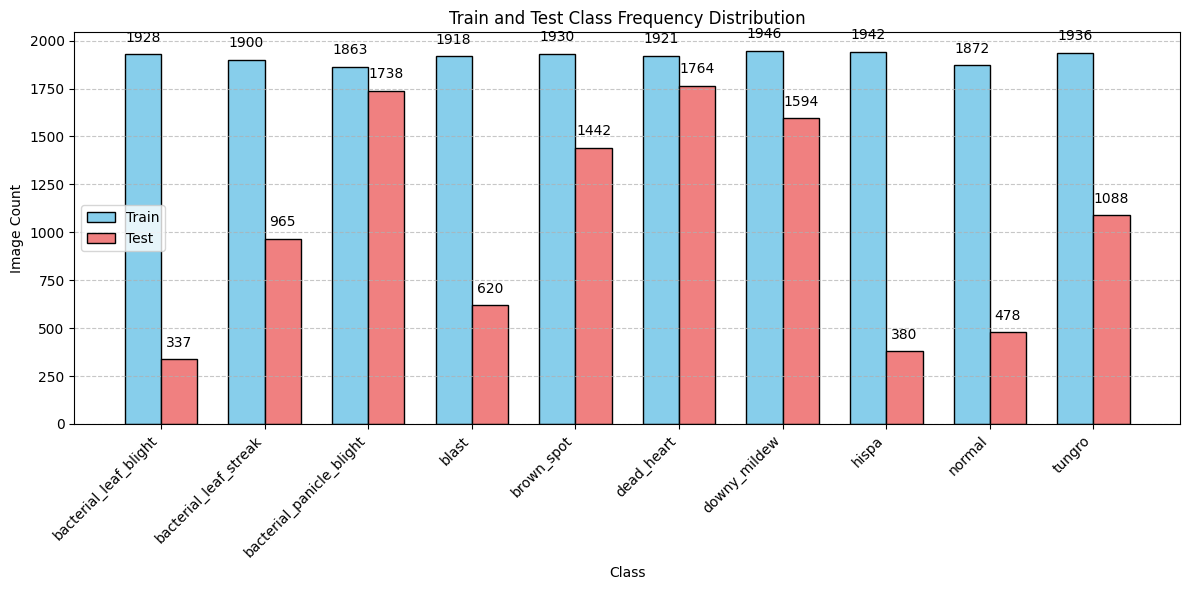


Member 2 processing complete. Files saved to outputs & visualizations.


In [ ]:
import pandas as pd
import json
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from pathlib import Path
import os
import pickle


def get_class_counts(folder_path):
    """Compute class counts from folder structure if CSV files are unavailable."""
    return {cls: len(os.listdir(os.path.join(folder_path, cls)))
            for cls in os.listdir(folder_path) if os.path.isdir(os.path.join(folder_path, cls))}

def load_or_compute_counts(train_path, test_path, train_csv, test_csv):
    """Load class counts from CSV or compute from folders."""
    try:
        train_counts = pd.read_csv(train_csv, index_col=0)["train_count"].to_dict()
        test_counts = pd.read_csv(test_csv, index_col=0)["test_count"].to_dict()
        print("Loaded class distributions from CSV.")
    except Exception as e:
        print(f"Error loading CSVs: {e}. Computing counts from folders.")
        train_counts = get_class_counts(train_path)
        test_counts = get_class_counts(test_path)
        # Save computed counts to CSV for future use
        pd.DataFrame({"class": list(train_counts.keys()), "train_count": list(train_counts.values())}).to_csv(train_csv, index=False)
        pd.DataFrame({"class": list(test_counts.keys()), "test_count": list(test_counts.values())}).to_csv(test_csv, index=False)
    return train_counts, test_counts

def cache_counts(counts, cache_file):
    """Cache counts to avoid recomputation."""
    with open(cache_file, "wb") as f:
        pickle.dump(counts, f)
    return counts

def load_cached_counts(cache_file):
    """Load cached counts if available."""
    if os.path.exists(cache_file):
        with open(cache_file, "rb") as f:
            return pickle.load(f)
    return None

def member2_encoding(train_path, test_path):
    """
    Member 2: Encode categorical variables (class names)
    - Label Encoding
    - Class Weights (for imbalanced classes)
    - Frequency Encoding
    - Save outputs & EDA visualization
    """
    print("="*60)
    print("MEMBER 2: CATEGORICAL ENCODING & FEATURE TRANSFORMATION")
    print("="*60)

    # Load class counts
    train_csv = OUTPUTS_DIR / "train_class_distribution.csv"
    test_csv = OUTPUTS_DIR / "test_class_distribution.csv"
    train_counts_cache = OUTPUTS_DIR / "train_counts.pkl"
    test_counts_cache = OUTPUTS_DIR / "test_counts.pkl"

    # Try loading cached counts
    train_counts = load_cached_counts(train_counts_cache)
    test_counts = load_cached_counts(test_counts_cache)

    if train_counts is None or test_counts is None:
        train_counts, test_counts = load_or_compute_counts(train_path, test_path, train_csv, test_csv)
        cache_counts(train_counts, train_counts_cache)
        cache_counts(test_counts, test_counts_cache)

    print("Train Class Distribution:", train_counts)
    print("Test Class Distribution:", test_counts)

    # Validate class consistency
    classes = sorted(train_counts.keys())
    if set(classes) != set(test_counts.keys()):
        print("Warning: Train and test classes differ. Using train classes.")

    print(f"Found {len(classes)} classes: {classes}")

    #Label Encoding
    try:
        label_encoder = LabelEncoder()
        label_encoder.fit(classes)
        encoded_labels = {cls: int(label_encoder.transform([cls])[0]) for cls in classes}
        print("\nLabel Encoding Mapping:", encoded_labels)
        with open(OUTPUTS_DIR / "label_mapping.json", "w") as f:
            json.dump(encoded_labels, f, indent=2)
    except Exception as e:
        print(f"Error in label encoding: {e}")

    #Class Weights 
    try:
        total_images = sum(train_counts.values())
        class_weights = {encoded_labels[cls]: total_images / (len(classes) * count)
                         for cls, count in train_counts.items()}
        print("\nClass Weights:", class_weights)
        with open(OUTPUTS_DIR / "class_weights.json", "w") as f:
            json.dump(class_weights, f, indent=2)
    except Exception as e:
        print(f"Error computing class weights: {e}")

    #Frequency Encoding
    try:
        freq_encoding = {cls: count / total_images for cls, count in train_counts.items()}
        print("\nFrequency Encoding (Normalized):", freq_encoding)
        with open(OUTPUTS_DIR / "frequency_encoding.json", "w") as f:
            json.dump(freq_encoding, f, indent=2)
    except Exception as e:
        print(f"Error in frequency encoding: {e}")

    #Visualization
    plt.figure(figsize=(12, 6))
    bar_width = 0.35
    x = range(len(classes))
    plt.bar(x, train_counts.values(), width=bar_width, label="Train", color="skyblue", edgecolor="black")
    plt.bar([i + bar_width for i in x], test_counts.values(), width=bar_width, label="Test", color="lightcoral", edgecolor="black")
    plt.xlabel("Class")
    plt.ylabel("Image Count")
    plt.title("Train and Test Class Frequency Distribution")
    plt.xticks([i + bar_width/2 for i in x], classes, rotation=45, ha="right")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    for i, (train_val, test_val) in enumerate(zip(train_counts.values(), test_counts.values())):
        plt.text(i, train_val + 50, int(train_val), ha="center", va="bottom")
        plt.text(i + bar_width, test_val + 50, int(test_val), ha="center", va="bottom")
    plt.legend()
    savefig("encoding_class_frequency")
    plt.show()

    print("\nMember 2 processing complete. Files saved to outputs & visualizations.")

# Example usage
train_path = "/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/train"
test_path = "/content/drive/MyDrive/2025-Y2-S1-MLB-B12G1-02/data/test"
member2_encoding(train_path, test_path)


In [19]:
len(train_path)


57